# PW5

In [1]:
import cv2

In [5]:
# Read these images:
img1 = cv2.imread('images/dog_backpack.png')
img2 = cv2.imread('images/watermark_no_copy.png')

In [7]:
# verify the shape of img1
print(img1.shape)

(1401, 934, 3)


In [8]:
# verify the shape of img2
print(img2.shape)

(1280, 1277, 3)


In [9]:
import matplotlib.pyplot as plt
%matplotlib inline

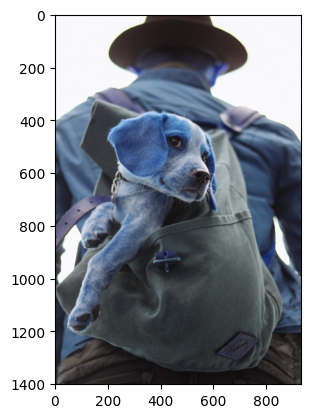

In [10]:
# plot img1
plt.imshow(img1)

Whoops! Let's remember to fix the RGB!

In [13]:
# fix the color distribition
img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)


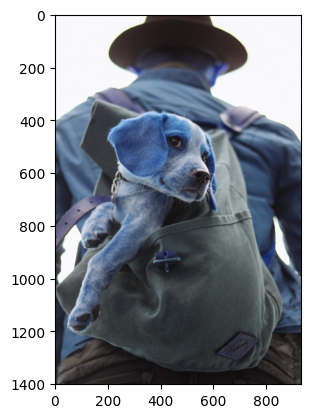

In [14]:
# plot img1 again
plt.imshow(img1)

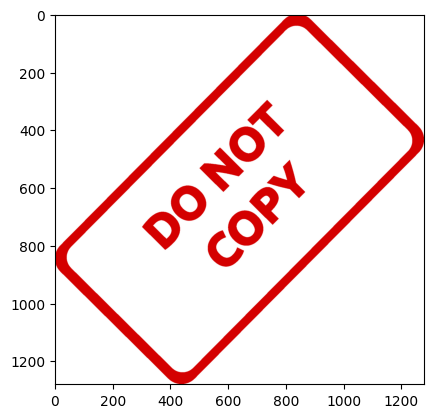

In [15]:
# plot img2
plt.imshow(img2)


### Resizing the Images

In [16]:
# resize img1 as (1200,1200)
# resize img2 as (1200,1200)
img1 = cv2.resize(img1, (1200,1200))
img2 = cv2.resize(img2, (1200,1200))

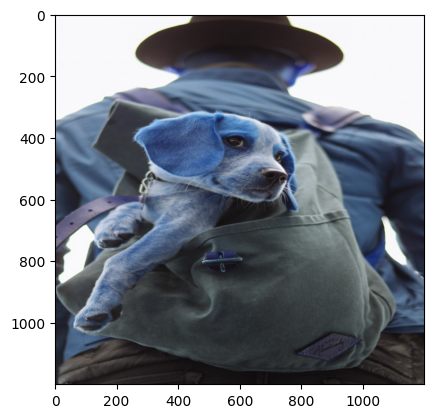

In [17]:
# plot img1
plt.imshow(img1)

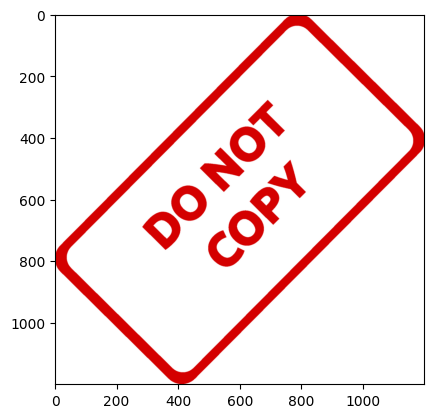

In [18]:
# plot img2
plt.imshow(img2)

### Blending the Image

We will blend the values together with the formula:

$$  img1 * \alpha  + img2 * \beta  + \gamma $$

In [19]:
# img1: shape
print(img1.shape)

(1200, 1200, 3)


In [20]:
# img2: shape
print(img2.shape)

(1200, 1200, 3)


In [21]:
# Blend img1 and img2 with: alpha=0.7, beta=0.3, gamma=0
blended = cv2.addWeighted(src1=img1, alpha=0.7, src2=img2, beta=0.3, gamma=0)

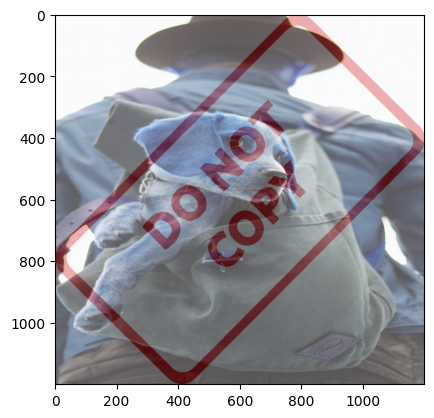

In [22]:
# plot blended image
plt.imshow(blended)

-----

## Overlaying Images of Different Sizes

We can use this quick trick to quickly overlap different sized images, by simply reassigning the larger image's values to match the smaller image.

In [23]:
# Load two images
#img1: dog_backpack.png
#img2: watermark_no_copy.png
#resize img2 (600,600)

#fix colors distribution of img1  
#fix colors distribution of img2  

img1 = cv2.imread('images/dog_backpack.png')
img2 = cv2.imread('images/watermark_no_copy.png')
img2 = cv2.resize(img2, (600,600))

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

large_img = img1
small_img = img2

In [24]:
x_offset=0
y_offset=0

In [25]:
# large_img: combine large_img and small_img
large_img[y_offset:y_offset+small_img.shape[0], x_offset:x_offset+small_img.shape[1]] = small_img

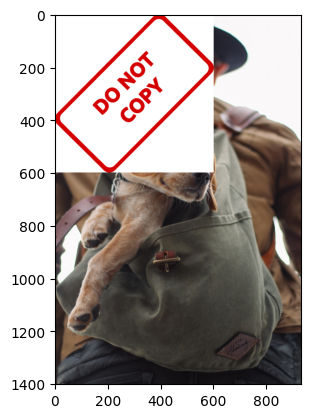

In [26]:
plt.imshow(large_img)

________
_______

## Blending Images of Different Sizes

### Imports

In [27]:
import numpy as np
import cv2

### Importing the images again and resizing

In [28]:
# Load two images
img1 = cv2.imread('images/dog_backpack.png')
img2 = cv2.imread('images/watermark_no_copy.png')
img2 =cv2.resize(img2,(600,600))

img1 = cv2.cvtColor(img1, cv2.COLOR_BGR2RGB)
img2 = cv2.cvtColor(img2, cv2.COLOR_BGR2RGB)

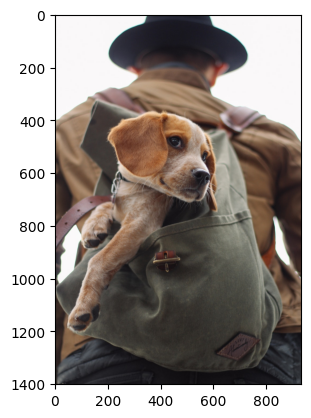

In [29]:
#plot img1   
plt.imshow(img1)

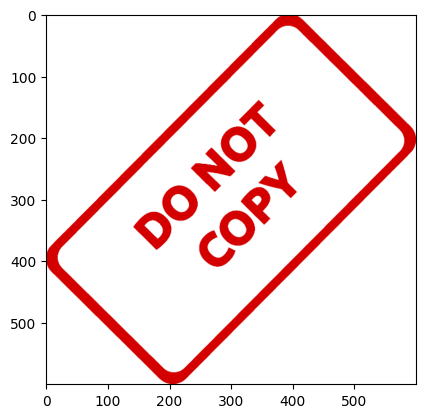

In [30]:
#plot img2   
plt.imshow(img2)

### Create a Region of Interest (ROI)

In [31]:
#img1 shape
print(img1.shape)

(1401, 934, 3)


In [32]:
x_offset=934-600
y_offset=1401-600

In [33]:
# Creating an ROI of the same size of the foreground image (smaller image that will go on top)
rows,cols,channels = img2.shape
# roi = img1[0:rows, 0:cols ] # TOP LEFT CORNER
# BOTTOM RIGHT CORNER
roi = img1[y_offset:1401,x_offset:934]

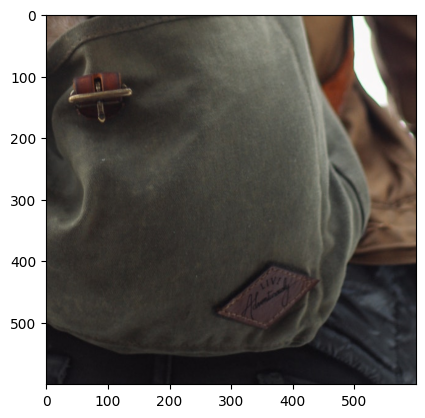

In [34]:
plt.imshow(roi)

In [35]:
# roi shape
print(roi.shape)

(600, 600, 3)


### Creating a Mask

In [36]:
# Now create a mask of logo and create its inverse mask also
img2gray = cv2.cvtColor(img2,cv2.COLOR_BGR2GRAY)

In [37]:
#img2gray shape
print(img2gray.shape)

(600, 600)


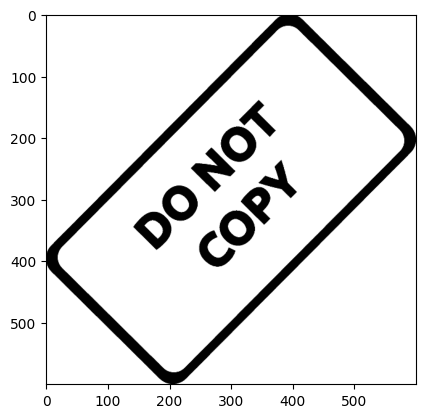

In [38]:
# plot img2gray (cmap='gray')
plt.imshow(img2gray, cmap='gray')

In [39]:
# use bitwise_not function to invert img2gray image
mask_inv = cv2.bitwise_not(img2gray)

In [40]:
# mask_inv shape
print(mask_inv.shape)

(600, 600)


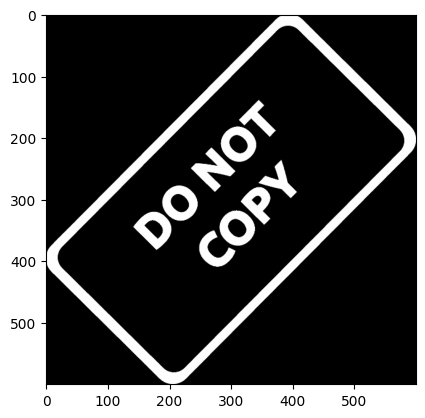

In [41]:
# plot mask_inv, cmap='gray'
plt.imshow(mask_inv, cmap='gray')

## Convert Mask to have 3 channels

In [42]:
white_background = np.full(img2.shape, 255, dtype=np.uint8)

In [43]:
#use bitwise_or image to add 2 layers on mask_inv image 
bk = cv2.bitwise_or(white_background, white_background, mask=mask_inv)

In [44]:
bk.shape

(600, 600, 3)

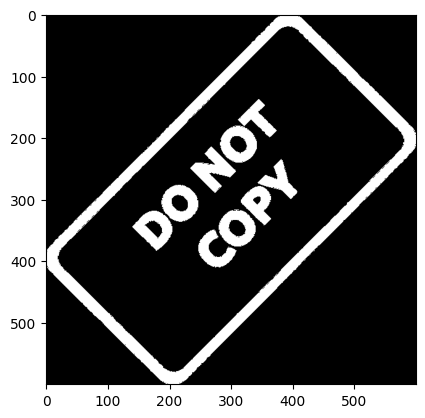

In [45]:
# plot  bk 
plt.imshow(bk)

### Grab Original FG image and place on top of Mask

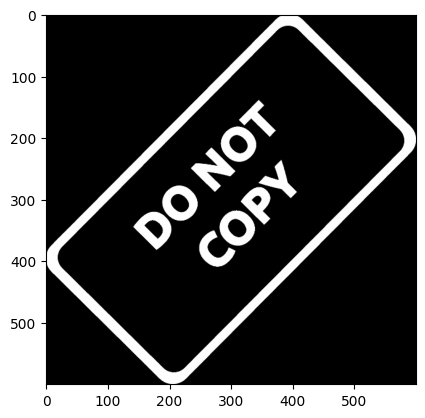

In [46]:
plt.imshow(mask_inv,cmap='gray')

In [47]:
fg = cv2.bitwise_or(img2, img2, mask=mask_inv)

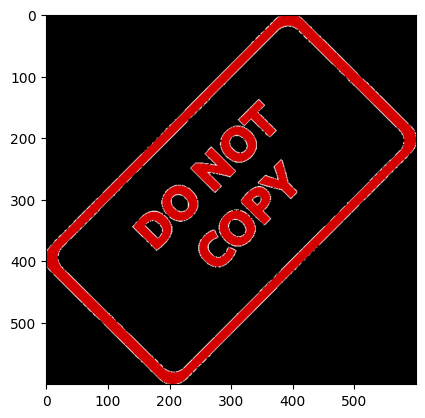

In [48]:
plt.imshow(fg)

In [49]:
fg.shape

(600, 600, 3)

### Get ROI and blend in the mask with the ROI

In [50]:
final_roi = cv2.bitwise_or(roi,fg)

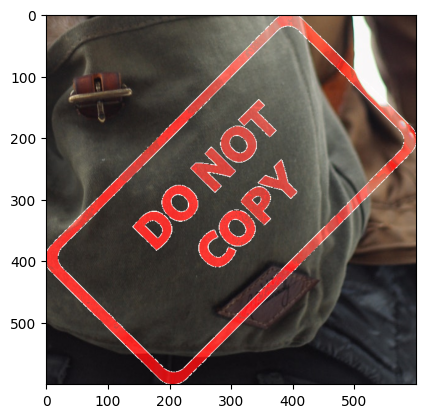

In [52]:
plt.imshow(final_roi)

### Now add in the rest of the image

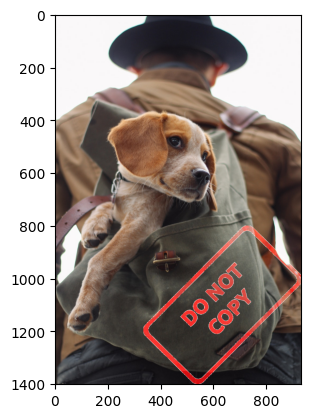

In [53]:
large_img = img1
small_img = final_roi


# large_img
large_img[y_offset:y_offset+small_img.shape[0], x_offset:x_offset+small_img.shape[1]] = small_img

# plot large_img
plt.imshow(large_img)

In [54]:
# Save this image in your PC and upload it with your notebook to the Moodle Page
# Thank you
cv2.imwrite('images/combined_image.png', cv2.cvtColor(large_img, cv2.COLOR_RGB2BGR))


True

### Great Work!

Check out these documentation examples and links for more help for these kinds of tasks (which can be really tricky!)

1. https://stackoverflow.com/questions/10469235/opencv-apply-mask-to-a-color-image/38493075
2. https://stackoverflow.com/questions/14063070/overlay-a-smaller-image-on-a-larger-image-python-opencv
3. https://docs.opencv.org/3.4/d0/d86/tutorial_py_image_arithmetics.html

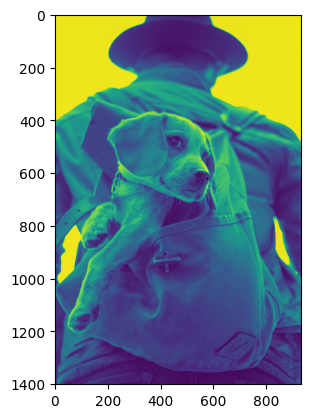

In [55]:
#pay attention, if your image is not a RGB image, cv.coclor_BGR2GRAY will not work correctely
import cv2 as cv
img1 = cv.imread('images/dog_backpack.png')
#im_color = cv.imread("lena.png", cv.IMREAD_COLOR)
im_gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
plt.imshow(im_gray)


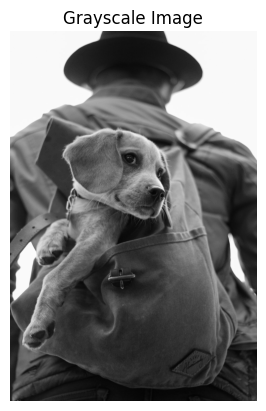

In [62]:
import cv2 as cv
import matplotlib.pyplot as plt

img1 = cv.imread("images/dog_backpack.png")
if img1 is None:
    print("Error: Image not found or failed to load.")
else:
    # Convert image to grayscale
    if len(img1.shape) == 3 and img1.shape[2] == 3:
        img_gray = cv.cvtColor(img1, cv.COLOR_BGR2GRAY)
        # Display using matplotlib
        plt.imshow(img_gray, cmap='gray')
        plt.title("Grayscale Image")
        plt.axis("off")  # Hide axes
        plt.show()
    else:
        print("Image is not in BGR format.")
